<a href="https://colab.research.google.com/github/Damianexe/CienciaDatos/blob/main/PCA_OrtizDamian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Investigacion Unidad 6

Damian Ortiz

Sección 1 — Estadística descriptiva

Cálculo de métricas

Dataset: Sample Superstore (Kaggle)
https://www.kaggle.com/datasets/vivek468/superstore-dataset-final


Dataset: 9994 filas, 21 columnas

RESUMEN ESTADÍSTICO
           Media  Mediana   Moda  Desv. Estándar   Varianza  Asimetría (skew)
Sales     229.86    54.49  12.96          623.25  388434.46             12.97
Quantity    3.79     3.00   3.00            2.23       4.95              1.28
Discount    0.16     0.20   0.00            0.21       0.04              1.68
Profit     28.66     8.67   0.00          234.26   54877.80              7.56


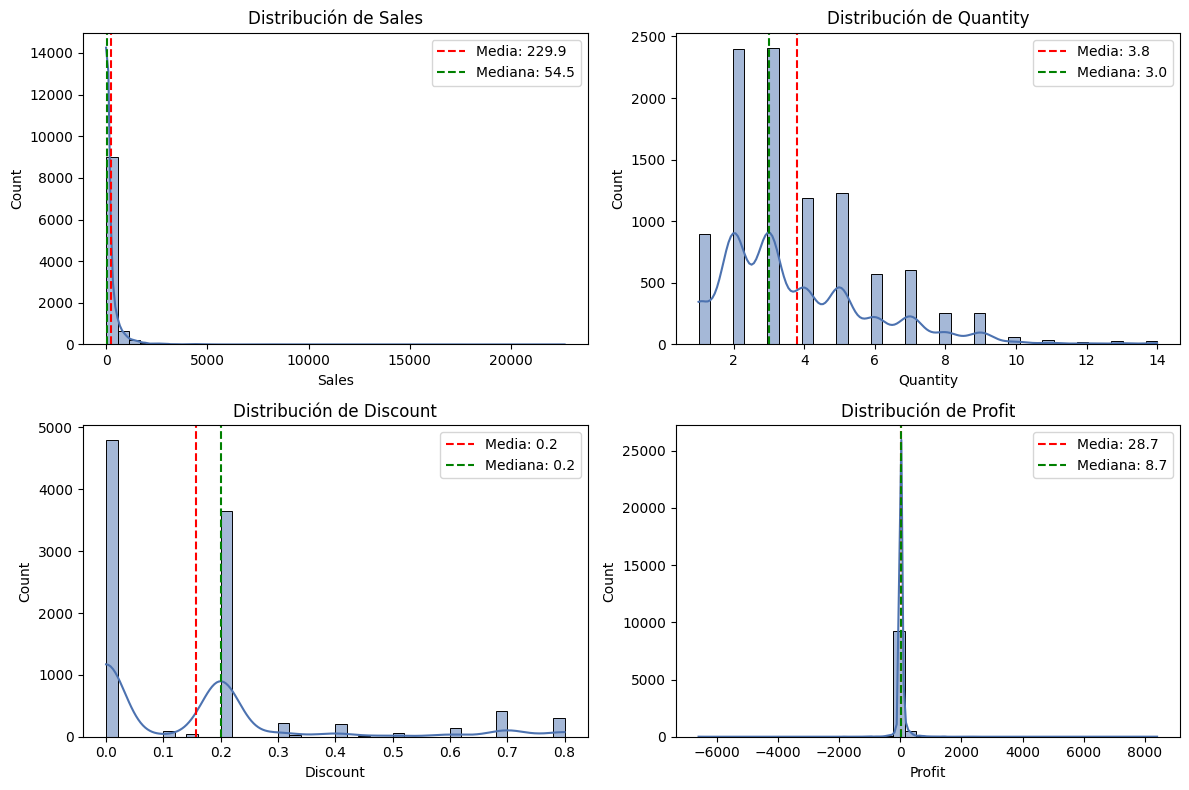


Archivo 'resumen_estadistico.csv' y 'distribuciones_superstore.png' generados.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------
# 1. Carga de datos
# ----------------------------------------------------
df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')

print(f"Dataset: {df.shape[0]} filas, {df.shape[1]} columnas\n")

# Variables numéricas de interés para el análisis
cols = ['Sales', 'Quantity', 'Discount', 'Profit']

# ----------------------------------------------------
# 2. Métricas de tendencia central y dispersión
# ----------------------------------------------------
media = df[cols].mean()
mediana = df[cols].median()
moda = df[cols].mode().iloc[0]
desviacion_std = df[cols].std()
varianza = df[cols].var()
asimetria = df[cols].skew()  # para saber hacia dónde se sesga la distribución

resumen = pd.DataFrame({
    'Media': media,
    'Mediana': mediana,
    'Moda': moda,
    'Desv. Estándar': desviacion_std,
    'Varianza': varianza,
    'Asimetría (skew)': asimetria
}).round(2)

print("=" * 70)
print("RESUMEN ESTADÍSTICO")
print("=" * 70)
print(resumen)

# ----------------------------------------------------
# 3. Distribución (histogramas)
# ----------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], bins=40, kde=True, ax=axes[i], color='#4C72B0')
    axes[i].axvline(media[col], color='red', linestyle='--', label=f'Media: {media[col]:.1f}')
    axes[i].axvline(mediana[col], color='green', linestyle='--', label=f'Mediana: {mediana[col]:.1f}')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].legend()

plt.tight_layout()
plt.savefig('distribuciones_superstore.png', dpi=150)
plt.show()

# ----------------------------------------------------
# 4. Exportar resumen para el informe
# ----------------------------------------------------
resumen.to_csv('resumen_estadistico.csv')
print("\nArchivo 'resumen_estadistico.csv' y 'distribuciones_superstore.png' generados.")